# XGBOOST PARA SEQUIA
En este documento voy a aplicar el modelo XGBOOST para predecir las accesiones que a traves de la metodología FIGS sea resitible a sequía
# ************************************************************************************************************************************************************

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)
from xgboost import XGBClassifier, plot_importance

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)


## Carga del dataset ##
El siguiente paso es cargar el dataset con las variables independientes. Esto garantiza que las variables climáticas y edáficas que quedan sean independientes entre sí, evitando redundancias estadísticas.
# **************************************************************************************************************************************************************

In [135]:
# Cargar dataset limpio y estandarizado
df = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")


## Creando la variable objetivo ##
La variable objetivo se basa en tres variables bioclimáticas.
* current_30arcsec_aridityIndexThornthwaite ==> Índice de aridez de Thornthwaite. Relación entre la precipitación y la evapotranspiración potencial anual. Valores bajos indican condiciones áridas.
* current_30arcsec_annualPET ==> Evapotranspiración potencial anual (PET). Estimación de la cantidad máxima de agua que podría evaporarse y transpirarse bajo condiciones ideales.
* current_30arcsec_climaticMoistureIndex ==> Índice de humedad climática (CMI). Mide el balance hídrico anual; valores positivos indican excedentes de agua, negativos, déficit.

In [136]:
df["Resistencia_Sequia"] = np.where(
    (df["current_30arcsec_aridityIndexThornthwaite"] < df["current_30arcsec_aridityIndexThornthwaite"].median()) &
    (df["current_30arcsec_annualPET"] < df["current_30arcsec_annualPET"].median()) &
    (df["current_30arcsec_climaticMoistureIndex"] > df["current_30arcsec_climaticMoistureIndex"].median()),
    1, 0
)

## Búsqueda de columnas categoricas ##
Es necesario eliminar las columnas que contienen identificadores ya que el modelo XGBOOST no las puede procesar como texto

In [137]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Columnas categóricas detectadas:")
print(cat_cols)

Columnas categóricas detectadas:
['DOI', 'ACCENUMB', 'CURATION', 'GENUS', 'SPECIES', 'GRIN_NAME', 'ORIGCTY', 'COLLSITE']


## Codificando columnas de tipo texto ##
Lo que se hace en el siguiente algoritmo es codificar aquellas columnas categoricas. Esto se hace ya que el modelo XGBOOST recibe entradas numéricas.

Desde la perspectiva FIGS, las variables categóricas como:

* GENUS, SPECIES → representan la identidad biológica de cada accesión.

* ORIGCTY → captura la región geográfica macro (proxy del contexto ecológico).

* COLLSITE o ACCENUMB → son metadatos de colecta.

En la práctica FIGS, estos campos no se eliminan, se codifican o se usan como factores de agrupamiento, porque muchas veces los patrones adaptativos tienen un componente geográfico o taxonómico.
Por ejemplo:

* Accesiones de Irán o Afganistán suelen agruparse en ambientes secos → potencial resistencia.

* Accesiones de Brasil o Colombia provienen de climas húmedos → control negativo natural.

Entonces, detectar las variables categóricas  permite decidir cuáles mantener como metadatos (para mapas, interpretación), cuáles incluir codificadas como predictores. Para este acso en especifico solo dejaré la columna ORIGCTY ya que puedo usarla como variable de contexto geográfico.

In [138]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


## Eliminando columnas predictoras ##
Se crea un dataframe X eliminando columnas que no voy a usar en el entrenamiento. el dataframe Y contien la variable a predecir.

Para este caso se consulto con expertos y se decidió eliminar varias columnas por el siguiente motivo:

| Columna                                                                                                                       | Motivo técnico / estadístico                                 | Riesgo sino se elimina                                                                          |
| ----------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------ | ------------------------------------------------------------------------------------------- |
| **Resistencia_Sequia**                                                                                                        | Es la variable objetivo, es decir, la avriable que se predice no puede estar en el input del modelo.  | Data leakage Tendría una variable que se auto predice.                                                  |
| **current_30arcsec_aridityIndexThornthwaite**<br>**current_30arcsec_annualPET**<br>**current_30arcsec_climaticMoistureIndex** | Se usaron para crear la variable objetivo.               | Fuerte correlación con *y* (filtración de información).                                     |
| **DECLATITUDE**, **DECLONGITUDE**                                                                                             | Coordenadas espaciales directas (no climáticas).             | El modelo podría “memorizar” ubicación geográfica en lugar de inferir patrones ambientales. |
| **DOI**, **ACCENUMB**                                                                                                         | Identificadores únicos de accesiones.                        | Sin significado biológico, generan sobreajuste.                                             |
| **CURATION**, **GRIN_NAME**                                                                                                   | Etiquetas administrativas o duplicadas de nombre taxonómico. | No aportan valor ecológico real, ruido textual.                                             |


In [139]:
y = df["Resistencia_Sequia"]
X = df.drop(columns=[
    "Resistencia_Sequia",
    "current_30arcsec_aridityIndexThornthwaite",
    "current_30arcsec_annualPET",
    "current_30arcsec_climaticMoistureIndex",
    "DECLATITUDE", "DECLONGITUDE",
    "DOI", "ACCENUMB", "CURATION", "GRIN_NAME"
])


In [140]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3357 entries, 0 to 3356
Data columns (total 58 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   GENUS                            3357 non-null   int32  
 1   SPECIES                          3357 non-null   int32  
 2   ORIGCTY                          3357 non-null   int32  
 3   COLLSITE                         3357 non-null   int32  
 4   SAMPSTAT                         3357 non-null   float64
 5   ELEVATION                        3357 non-null   float64
 6   COLLSRC                          3357 non-null   float64
 7   MODCF_CloudForestPrediction      3357 non-null   float64
 8   MODCF_meanannual                 3357 non-null   float64
 9   MODCF_seasonality_concentration  3357 non-null   float64
 10  current_30arcsec_continentality  3357 non-null   float64
 11  AWCh1_M_sl1                      3357 non-null   float64
 12  AWCh1_M_sl2         

## Entrenamiento del modelo ##
Entrenamiento del modelo con 80% de los datos para entrenamiento y 20% para prueba. Es importante ya que se garantiza las metricas que refelna le poder predicitivo y no memorización del algoritmo.

Una vez escalado el conjunto de entrenamiento se entrena el modelo a partir de cierto parametros que se pueden configurar de acuerdo a conveniencia.

| Parámetro                  | Qué hace                                                             | Por qué es importante                                                       |
| -------------------------- | -------------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **`n_estimators=300`**     | Número de árboles que se construirán.                                | Suficiente profundidad para capturar relaciones complejas sin sobreajustar. |
| **`learning_rate=0.05`**   | Controla cuánto corrige cada nuevo árbol (velocidad de aprendizaje). | Un valor bajo favorece la estabilidad y la generalización.                  |
| **`max_depth=6`**          | Profundidad máxima de cada árbol.                                    | Controla la complejidad (cuántas interacciones se modelan).                 |
| **`subsample=0.8`**        | Porcentaje de datos usados en cada iteración.                        | Introduce aleatoriedad y reduce el riesgo de sobreajuste.                   |
| **`colsample_bytree=0.8`** | Porcentaje de variables seleccionadas al construir cada árbol.       | Aumenta la diversidad del ensamble (similar a Random Forest).               |
| **`eval_metric='auc'`**    | Métrica base: Área Bajo la Curva ROC.                                | Ideal para problemas binarios (resistente / no resistente).                 |
| **`random_state=42`**      | Semilla de aleatoriedad.                                             | Garantiza reproducibilidad de los resultados.                               |


In [141]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [142]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [143]:
# =========================================================
# Entrenar modelo XGBoost
# =========================================================
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

## Obteniendo los resultados del entrenamiento ##
A continuación se obtiene los resultados del entrenamiento del modelo y las métricas que me permiten sabe si el modelo está prediciendo o memorizando


AUC: 0.9853814527181362
Accuracy: 0.9434523809523809
Precision: 0.8851674641148325
Recall: 0.9296482412060302
F1 Score: 0.9068627450980392


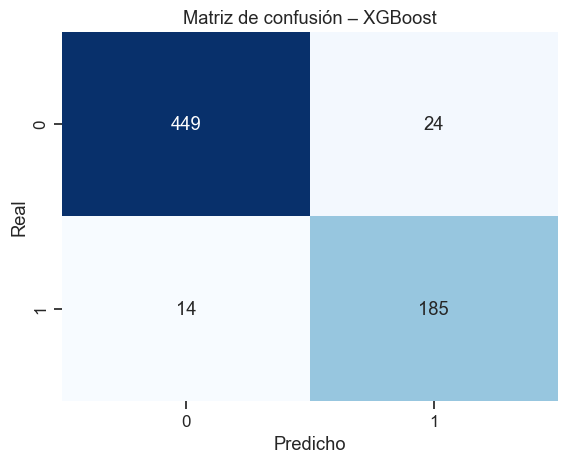

In [144]:
# Predicciones
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print("AUC:", roc_auc_score(y_test, y_prob))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de confusión – XGBoost")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()


## Analisis del resultado del entrenamiento ##
Una primera impresión es que el modelo XGBOOST captura de buena forma los patrones ecológicos de resistencia a sequía. A continuación muestro un analisis mas detallado sobbre las métricas obtenidas:

| Métrica                   | Valor | Interpretación técnica                                                                                       |
| ------------------------- | ----- | ------------------------------------------------------------------------------------------------------------ |
| **AUC**                   | 0.985 | El modelo distingue correctamente accesiones resistentes (1) y no resistentes (0) en el 98.5 % de los casos. |
| **Accuracy (Exactitud)**  | 0.943 | El 94.3 % de las predicciones totales son correctas.                                                         |
| **Precision (Precisión)** | 0.885 | De todas las accesiones predichas como resistentes, el 88.5 % realmente lo son.                              |
| **Recall (Sensibilidad)** | 0.929 | El 92.9 % de las accesiones realmente resistentes fueron identificadas por el modelo.                        |
| **F1 Score**              | 0.907 | Promedio armónico entre precisión y recall; mide equilibrio general.                                         |

La matriz de confusión me permite observar loa verdaderos y falsos negativos asi como los verdaderos y falso positivos. En la siguiente tabla detallo los resultados obtenidos en la gráfica.

|                              | Predicho = 0 | Predicho = 1 |
| ---------------------------- | ------------ | ------------ |
| **Real = 0** (no resistente) | 449          | 24           |
| **Real = 1** (resistente)    | 14           | 185          |

De lo anterior se puede definir que:

* 449 → verdaderos negativos (modelo acierta: no resistentes correctamente detectados).
* 185 → verdaderos positivos (modelo acierta: resistentes correctamente detectados).
* 24 → falsos positivos (predijo resistencia donde no había).
* 14 → falsos negativos (no detectó resistencia en accesiones resistentes).
* El modelo tiene muy pocos errores (apenas 38 de 672 muestras).
* El recall es mayor que la precisión, lo cual indica que el modelo prefiere detectar todas las accesiones resistentes, aunque ocasionalmente marque alguna falsa positiva. Esto es interesante ya que en FIGS se busca excluir candidatos resistentes, sino capturar el mayor número posible de adaptados.

## Curva ROC ##
La curva ROC (Receiver Operating Characteristic) me permite evalúar la capacidad del modelo para distinguir entre accesiones resistentes (1) y no resistentes (0) a distintos umbrales de decisión.

* Eje X:  proporción de no resistentes que fueron incorrectamente clasificados como resistentes.
* Eje Y:  proporción de resistentes correctamente identificados (también llamado recall o sensibilidad).



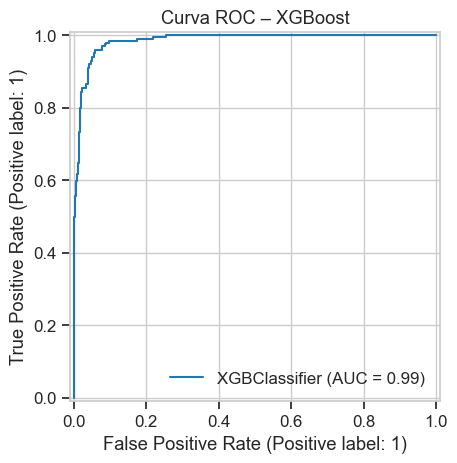

In [145]:
RocCurveDisplay.from_estimator(xgb_model, X_test_scaled, y_test)
plt.title("Curva ROC – XGBoost")
plt.show()


De acuerdo al resultado AUC, en el 99 % de los pares posibles de accesiones (una resistente, una no resistente), el modelo asigna una probabilidad más alta de resistencia a la accesión realmente resistente, es decir, que el modelo distingue con casi total precisión los ambientes ecológicos asociados con sequía.

Desde el punto de vista biológico, el comportamiento observado (AUC alto, curva empinada) indica que las variables bioclimáticas (bio15, bio19) y los parámetros edáficos (pH, textura) combinadas logran distinguir efectivamente ambientes áridos y húmedos. Esto es coherente con la adaptación fisiológica del Phaseolus vulgaris, que exhibe diferenciación eco-geográfica clara entre razas Mesoamericanas (más resistentes) y Andinas (más húmedas). dicho de otra forma, el modelo redescubre empíricamente la separación ecológica que la biología ya sugiere. 

Podemos ver las varables importantes en la siguinete gráfica:

<Figure size 1000x600 with 0 Axes>

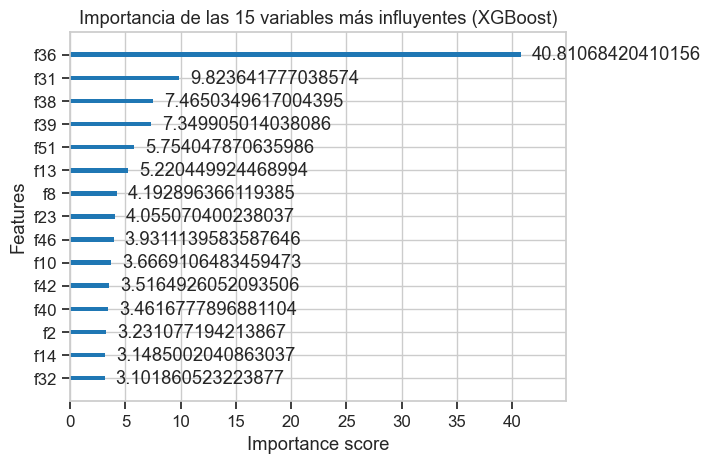

In [146]:
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, max_num_features=15, importance_type='gain')
plt.title("Importancia de las 15 variables más influyentes (XGBoost)")
plt.show()


## Decodificando las variables para entender la gráfica de imprtancia de las variables ##

In [147]:
# =========================================================
# Recuperar nombres de variables reales para cada fN
# =========================================================

import pandas as pd

# Extraer las importancias del modelo
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')

# Crear DataFrame con esas importancias
feature_importances = (
    pd.DataFrame(importance_dict.items(), columns=['feature', 'importance_gain'])
    .sort_values(by='importance_gain', ascending=False)
)

# Construir un mapeo manual entre fN y las columnas originales
feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}

# Agregar la columna con el nombre real
feature_importances["variable_real"] = feature_importances["feature"].map(feature_map)

# Reorganizar columnas
feature_importances = feature_importances[["feature", "variable_real", "importance_gain"]]

# Mostrar las variables principales
print("Top 15 variables más influyentes (XGBoost):")
print(feature_importances.head(15))


Top 15 variables más influyentes (XGBoost):
   feature                    variable_real  importance_gain
33     f36                            bio15        40.810684
28     f31                             bio1         9.823642
35     f38                            bio19         7.465035
36     f39                             bio2         7.349905
48     f51                          srad_10         5.754048
11     f13                      AWCtS_M_sl1         5.220450
6       f8                 MODCF_meanannual         4.192896
21     f23                     PHIHOX_M_sl1         4.055070
43     f46                           prec_4         3.931114
8      f10  current_30arcsec_continentality         3.666911
39     f42                             bio9         3.516493
37     f40                             bio3         3.461678
0       f2                          ORIGCTY         3.231077
12     f14                     CECSOL_M_sl1         3.148500
29     f32                            bio

 ## Guardando las métricas, los resultados y prueba del método con una variable nueva simulada ##
 Se guardan métricas y resultados de las variables importantes y prueba del método con una variable nueva simulada, esta última para visualizar en un powerBI

In [148]:
# =========================================================
# Métricas (XGBOOST)
# =========================================================
metrics = {
    'AUC': roc_auc_score(y_test, y_prob),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv("./dataset_salida/resultados_metricas_xgboost.csv", index=False)
print("Resultados exportados a 'dataset_salida/resultados_xgboost.csv'")


Resultados exportados a 'dataset_salida/resultados_xgboost.csv'


In [149]:
# =========================================================
# Importancia de variables con nombres originales (XGBoost)
# =========================================================

import pandas as pd

# Extrayendo las importancias directamente del modelo
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')

# Crear un DataFrame ordenado por importancia
feature_importances = (
    pd.DataFrame(importance_dict.items(), columns=['feature', 'importance_gain'])
    .sort_values(by='importance_gain', ascending=False)
)

# Mapeando cada "fN" al nombre real de columna
feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
feature_importances["variable_real"] = feature_importances["feature"].map(feature_map)

# Reorganizando columnas
feature_importances = feature_importances[["feature", "variable_real", "importance_gain"]]

# Mostrar el top de las variables mas influyentes
print("Top 15 variables más influyentes (XGBoost):")
display(feature_importances.head(15))

# Guardar resultados en CSV
ruta_salida = "./dataset_salida/importancia_variables_xgboost.xlsx"
feature_importances.to_excel(ruta_salida, index=False)

print(f"\nArchivo exportado correctamente en: {ruta_salida}")


Top 15 variables más influyentes (XGBoost):


,feature,variable_real,importance_gain
33,f36,bio15,40.810684
28,f31,bio1,9.823642
35,f38,bio19,7.465035
36,f39,bio2,7.349905
48,f51,srad_10,5.754048
11,f13,AWCtS_M_sl1,5.220450
6,f8,MODCF_meanannual,4.192896
21,f23,PHIHOX_M_sl1,4.055070
43,f46,prec_4,3.931114
8,f10,current_30arcsec_continentality,3.666911



Archivo exportado correctamente en: ./dataset_salida/importancia_variables_xgboost.xlsx


In [150]:
# =========================================================
# Recuperar nombres originales y coordenadas para visualización
# =========================================================

# Cargar nuevamente el dataset original SIN codificar
df_original = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")

# Volver a crear la variable objetivo (por coherencia)
df_original["Resistencia_Sequia"] = np.where(
    (df_original["current_30arcsec_aridityIndexThornthwaite"] < df_original["current_30arcsec_aridityIndexThornthwaite"].median()) &
    (df_original["current_30arcsec_annualPET"] < df_original["current_30arcsec_annualPET"].median()) &
    (df_original["current_30arcsec_climaticMoistureIndex"] > df_original["current_30arcsec_climaticMoistureIndex"].median()),
    1, 0
)

# Crear un DataFrame con solo identificadores
meta_cols = ["DOI", "ACCENUMB", "ORIGCTY", "DECLATITUDE", "DECLONGITUDE"]
meta_info = df_original[meta_cols]

# Generar predicciones y probabilidades con el modelo entrenado
predicciones = xgb_model.predict(X)
probabilidades = xgb_model.predict_proba(X)[:, 1]

# Crear DataFrame final combinando la metadata con resultados del modelo
resultados = pd.concat([meta_info], axis=1)
resultados["Pred_Resistencia"] = predicciones
resultados["Probabilidad_Resistencia"] = probabilidades

# Guardar el archivo para Power BI o GIS
ruta_resultados = "./dataset_salida/predicciones_xgboost_geolocalizadas.csv"
resultados.to_csv(ruta_resultados, index=False)

print(f"Archivo exportado: {ruta_resultados}")
display(resultados.head(10))


Archivo exportado: ./dataset_salida/predicciones_xgboost_geolocalizadas.csv


,DOI,ACCENUMB,ORIGCTY,DECLATITUDE,DECLONGITUDE,Pred_Resistencia,Probabilidad_Resistencia
0,10.18730/JKECH,G16570,IRN,35.81,50.93,0,0.001862
1,10.18730/JKEKR,G16576,IRN,34.32,47.07,0,0.001202
2,10.18730/JZXX0,G990,IRN,31.32,48.70,0,0.000310
3,10.18730/JZXWU,G989,IRN,29.62,51.63,0,0.000391
4,10.18730/JZXT$,G987,IRN,29.60,52.53,0,0.000312
5,10.18730/JZXNX,G980,IRN,38.08,46.30,1,0.595610
6,10.18730/JZXKV,G978,IRN,37.55,45.07,0,0.011669
7,10.18730/JZXJT,G977,IRN,34.80,48.50,0,0.001618
8,10.18730/JZWY6,G965,IRN,35.67,51.43,0,0.006536
9,10.18730/JNE6R,G9506,IRN,36.35,59.61,0,0.000807
